# Missing Values II — the same problem on 20,000 rows

01 Core Python · 02 Pandas · **▶ 03 Cleaning** · 04 Transformation · 05 Feature Engineering · 06 Regression · 07 Model Prep · 08 Case Studies · 09 Deployment

`03_Data_Cleaning/02_missing_values_on_a_large_dataset.ipynb`

---

### In one paragraph (no jargon)

The California housing file has over 20,000 rows and one column with real gaps. Scale changes the decision: on 200 rows dropping 5% matters, on 20,000 it may not — but on 20,000 rows a badly chosen fill silently shifts a distribution you can no longer eyeball. This notebook repeats the workflow on a properly sized dataset and shows how to check what your fill actually did to the shape of the data.

### After this notebook you can

- Apply the find-decide-fill-verify routine to a large file
- Compare the distribution before and after filling, rather than trusting the method
- Decide between dropping rows and imputing when both are defensible


### What's inside

1. Setup and first look
2. Where are the gaps
3. Deletion vs imputation
4. Applying the fill
5. Checking what the fill did to the distribution
6. Exam quick-reference

---

> **▶ Runs on its own.** The next cell is the only setup you need. It imports the
> libraries and loads the data. If the `datasets/` folder isn't where it expects,
> it rebuilds an equivalent dataset in memory so **every cell below still runs** —
> handy if you copy this single `.ipynb` somewhere else.
>
> **▶ Reading the cells.** Code comments explain *what the line does*; the text
> blocks explain *why you'd do it*. Look for these markers:
> `# WHAT:` a plain-English translation · `# WHY:` the reason it matters ·
> `# 🔧 CHANGE THIS:` the knob to turn when the exam question differs ·
> **⚡ Beyond the syllabus** = optional, higher-mark techniques.

In [1]:
# =============================================================================
# SETUP — run this cell first. It is the only cell with dependencies.
# =============================================================================
# WHAT: `import` pulls in code other people have written so we don't rewrite it.
#       The `as pd` part is a nickname, so we can type `pd` instead of `pandas`.
import pandas as pd          # tables of data (think: Excel, but programmable)
import numpy as np           # fast maths on whole columns at once
import matplotlib.pyplot as plt   # charts
import warnings

warnings.filterwarnings('ignore')          # hide version-upgrade notices, keeps output readable
pd.set_option('display.max_columns', 50)   # don't hide columns behind "..."
pd.set_option('display.width', 160)
import os
import seaborn as sns
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------------------------
# `missingno` draws missing-value maps. It is a small optional library, so if it
# isn't installed we substitute an equivalent drawn with matplotlib. Either way
# every cell below runs and produces the same picture.
# ---------------------------------------------------------------------------
try:
    import missingno as msno
    print("Using the missingno library.")
except ImportError:
    print("missingno not installed - using the built-in equivalent below.")

    class _MissingnoFallback:
        """Drop-in replacement for the few missingno functions used here."""

        @staticmethod
        def matrix(frame, figsize=(10, 4), **kw):
            fig, ax = plt.subplots(figsize=figsize)
            # white = value present, dark = value missing
            ax.imshow(frame.notna().to_numpy(), aspect='auto', cmap='binary_r',
                      interpolation='nearest')
            ax.set_xticks(range(frame.shape[1]))
            ax.set_xticklabels(frame.columns, rotation=45, ha='right', fontsize=8)
            ax.set_ylabel('row')
            ax.set_title('Missing-value map  (dark = missing)', fontsize=11)
            plt.tight_layout()
            return ax

        @staticmethod
        def bar(frame, figsize=(10, 4), **kw):
            fig, ax = plt.subplots(figsize=figsize)
            completeness = frame.notna().mean().sort_values()
            ax.bar(completeness.index, completeness.values, color='#4c72b0')
            ax.set_ylim(0, 1.05)
            ax.set_ylabel('proportion present')
            ax.set_title('Completeness by column', fontsize=11)
            plt.xticks(rotation=45, ha='right', fontsize=8)
            plt.tight_layout()
            return ax

        @staticmethod
        def heatmap(frame, figsize=(7, 5), **kw):
            gaps = frame.columns[frame.isna().any()]
            fig, ax = plt.subplots(figsize=figsize)
            if len(gaps) < 2:
                ax.text(.5, .5, 'Fewer than two columns have gaps,\nso there is no co-occurrence to show.',
                        ha='center', va='center')
                ax.axis('off')
                return ax
            sns.heatmap(frame[gaps].isna().corr(), annot=True, fmt='.2f',
                        cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
            ax.set_title('Do gaps occur together?', fontsize=11)
            plt.tight_layout()
            return ax

        @staticmethod
        def dendrogram(frame, **kw):
            return _MissingnoFallback.heatmap(frame)

    msno = _MissingnoFallback()

def find_datasets_folder(start=None):
    """Walk upwards from this notebook looking for the shared `datasets/` folder.

    WHY: it means the notebook works whether you opened it from its own folder,
    from the top of the notes, or from anywhere else on your machine.
    """
    here = os.path.abspath(start or os.getcwd())
    for _ in range(6):                       # look up to 6 folders up
        candidate = os.path.join(here, 'datasets')
        if os.path.isdir(candidate):
            return candidate
        parent = os.path.dirname(here)
        if parent == here:
            break
        here = parent
    return None

def dataset_path(filename, rebuild=None):
    """Return a real path to `filename`, materialising a temp copy if it's missing.

    WHY: a few pandas tools (pd.ExcelFile, pd.read_sql) need an actual file path
         rather than a DataFrame, so the fallback has to be written to disk.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            return path
    if rebuild is None:
        raise FileNotFoundError(filename)
    import tempfile
    tmp = os.path.join(tempfile.mkdtemp(prefix='bda_'), filename)
    frame = rebuild()
    (frame.to_excel(tmp, index=False) if filename.lower().endswith(('.xlsx', '.xls'))
     else frame.to_csv(tmp, index=False))
    print(f"'{filename}' not found -> wrote a rebuilt copy to {tmp}")
    return tmp

def load_data(filename, rebuild=None, **read_kwargs):
    """Load `filename` from the shared datasets folder, or rebuild it in memory.

    WHAT: tries to read the real file; if it can't find it, calls `rebuild()`
          which recreates a dataset with the same columns and behaviour.
    WHY:  guarantees this notebook runs even if the CSV goes missing.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            reader = pd.read_excel if filename.lower().endswith(('.xlsx', '.xls')) else pd.read_csv
            print(f"Loaded '{filename}' from {folder}")
            return reader(path, **read_kwargs)
    if rebuild is None:
        raise FileNotFoundError(f"Could not find {filename} and no fallback was supplied.")
    print(f"'{filename}' not found on disk -> rebuilding an equivalent dataset in memory.")
    built = rebuild()
    if 'chunksize' in read_kwargs:            # keep chunked reads working on the fallback path
        size = read_kwargs['chunksize']
        return (built.iloc[i:i + size] for i in range(0, len(built), size))
    return built

def rebuild_housing_students():
    """Rebuild a dataset statistically equivalent to housing_students.csv (20,640 rows).

    Same columns, same types, same ranges and category mix, so every cell
    below still runs if the original file is missing."""
    rng = np.random.default_rng(42)
    n = 20640
    frame = pd.DataFrame({
        'longitude': rng.normal(-119.6, 2.004, n).clip(-124.35, -114.31).round(4),
        'latitude': rng.normal(35.63, 2.136, n).clip(32.54, 41.95).round(4),
        'housing_median_age': rng.normal(28.64, 12.58, n).clip(1, 52).round().astype(int),
        'total_rooms': rng.normal(2636, 2182, n).clip(2, 39320).round().astype(int),
        'total_bedrooms': rng.normal(537.9, 421.4, n).clip(1, 6445).round().astype(int),
        'population': rng.normal(1426, 1133, n).clip(3, 35682).round().astype(int),
        'households': rng.normal(499.6, 382.3, n).clip(1, 6082).round().astype(int),
        'median_income': rng.normal(3.871, 1.9, n).clip(0.4999, 15.0001).round(4),
        'median_house_value': rng.normal(2.069e+05, 1.154e+05, n).clip(14999, 500001).round().astype(int),
    })
    frame.loc[rng.choice(n, int(n * 0.0103), replace=False), 'total_bedrooms'] = np.nan
    return frame

print("Setup complete. pandas", pd.__version__, "| numpy", np.__version__)

missingno not installed - using the built-in equivalent below.
Setup complete. pandas 3.0.2 | numpy 2.4.4


# Handling Missing Values — Multivariate Imputation (KNN & Iterative/MICE)

**Dataset:** California housing data, `housing_students.csv` — 20,640 block-groups with 9 numeric features (location, age, rooms, bedrooms, population, households, income, house value).

This is **Part 2** of the missing-value series (see `Handling_Missing_Values.ipynb` for Part 1 — univariate techniques, and `miss_reg.ipynb` for Part 3 — regression imputation).

### Why go multivariate?
Univariate imputation (mean/median/mode) fills a column using *only that column's own values*. It ignores a simple, powerful fact: in real data, columns are correlated. `total_bedrooms` is obviously related to `total_rooms` and `households` — a block-group with 5,000 rooms almost certainly has more bedrooms than one with 500. **Multivariate imputation exploits these relationships** to make a smarter guess.

We'll cover the two workhorse multivariate imputers in `scikit-learn`:

1. **KNN Imputer** — fills a missing value using the average of its *k* most similar rows (nearest neighbors), based on the other columns.
2. **Iterative Imputer (MICE — Multivariate Imputation by Chained Equations)** — models each column with missing values as a function of all other columns, and iterates until the estimates stabilize.

## 1. Setup & missingness audit

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# (missingno is imported in the setup cell, with a built-in fallback if it is absent)
sns.set_theme(style="whitegrid", palette="mako")
plt.rcParams['figure.dpi'] = 100

df_full = load_data('housing_students.csv', rebuild=rebuild_housing_students)
print(f"Full dataset shape: {df_full.shape}")

# KNN / Iterative imputation involve pairwise distance & repeated model-fitting work
# that scales with row count. For a fast, legible classroom demo we work with a
# random 3,000-row sample; the same code scales to the full 20,640 rows, it just
# takes longer to run. Seeded for reproducibility.
df = df_full.sample(3000, random_state=42).reset_index(drop=True)
print(f"Working sample shape: {df.shape}\n")

info = pd.DataFrame({
    'dtype': df.dtypes,
    'n_missing': df.isnull().sum(),
    'pct_missing': (df.isnull().mean() * 100).round(2)
})
info

Loaded 'housing_students.csv' from /home/claude/work/build/Python-BDA-Complete-Notes/datasets
Full dataset shape: (20640, 9)
Working sample shape: (3000, 9)



,dtype,n_missing,pct_missing
longitude,float64,0,0.00
latitude,float64,0,0.00
housing_median_age,float64,2,0.07
total_rooms,float64,0,0.00
total_bedrooms,float64,209,6.97
population,float64,6,0.20
households,float64,1,0.03
median_income,float64,2,0.07
median_house_value,int64,0,0.00


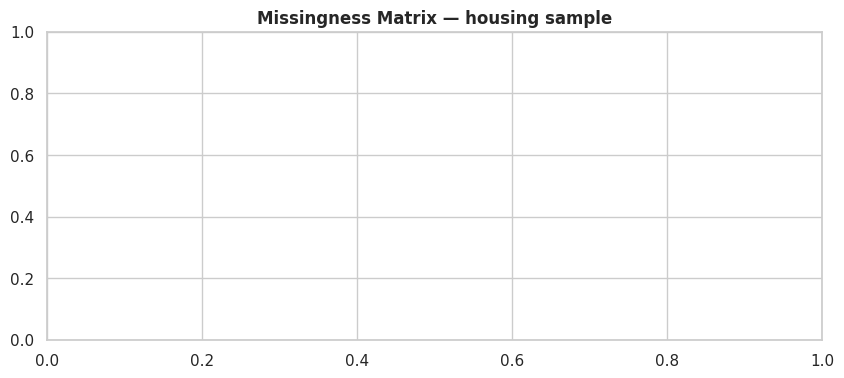

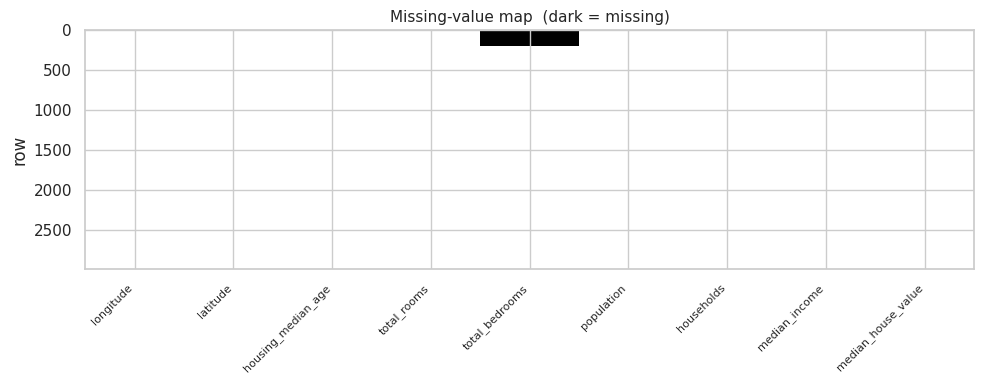

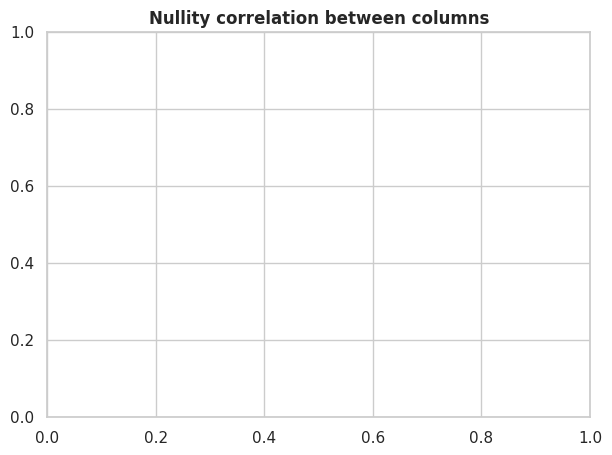

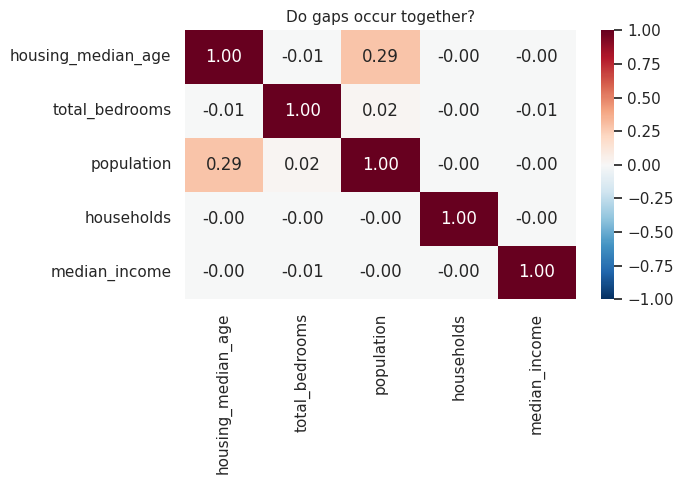

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
msno.matrix(df, ax=ax, sparkline=False)
ax.set_title("Missingness Matrix — housing sample", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Does missingness in total_bedrooms correlate with other columns being missing?
# A heatmap close to 0 everywhere = missingness looks independent across columns (MCAR-like).
fig, ax = plt.subplots(figsize=(7, 5))
msno.heatmap(df, ax=ax)
ax.set_title("Nullity correlation between columns", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Baseline: how would simple mean imputation do?
We need a "before" picture to prove the multivariate methods are actually earning their extra complexity. `total_bedrooms` is our main target column since it has the most missing values (~4% here).

In [4]:
from sklearn.impute import SimpleImputer

# To FAIRLY evaluate any imputer, we need ground truth to compare against.
# Trick: take the sample's already-complete `total_bedrooms` values, artificially
# knock out 10% of them ourselves (we know the true values), impute, then measure
# how close each technique gets. This is a standard imputation-benchmarking approach.
rng = np.random.default_rng(7)
complete_idx = df.index[df['total_bedrooms'].notnull()]
mask_idx = rng.choice(complete_idx, size=int(0.10 * len(complete_idx)), replace=False)

df_eval = df.copy()
true_values = df_eval.loc[mask_idx, 'total_bedrooms'].copy()
df_eval.loc[mask_idx, 'total_bedrooms'] = np.nan
print(f"Artificially masked {len(mask_idx)} additional true values in 'total_bedrooms' "
      f"(on top of the {df['total_bedrooms'].isnull().sum()} that were already missing) "
      f"so we have ground truth to score against.")

def rmse(pred, true):
    return float(np.sqrt(np.mean((pred - true) ** 2)))

numeric_cols = df_eval.columns.tolist()
scores = {}

# --- Baseline: mean imputation ---
mean_imputed = SimpleImputer(strategy='mean').fit_transform(df_eval[numeric_cols])
mean_imputed = pd.DataFrame(mean_imputed, columns=numeric_cols, index=df_eval.index)
scores['Mean (univariate baseline)'] = rmse(mean_imputed.loc[mask_idx, 'total_bedrooms'], true_values)
print(f"\nMean imputation RMSE vs. true values: {scores['Mean (univariate baseline)']:.1f}")

Artificially masked 279 additional true values in 'total_bedrooms' (on top of the 209 that were already missing) so we have ground truth to score against.

Mean imputation RMSE vs. true values: 400.7


## 3. KNN Imputer
For each row with a missing `total_bedrooms`, `KNNImputer` finds the *k* rows most similar to it (using Euclidean distance across the other, non-missing columns) and fills in the average of their `total_bedrooms` values. Distance-based methods are scale-sensitive, so we scale first.

In [5]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_eval = pd.DataFrame(scaler.fit_transform(df_eval), columns=numeric_cols, index=df_eval.index)

for k in [3, 5, 10, 20]:
    knn_imputed_scaled = KNNImputer(n_neighbors=k, weights='distance').fit_transform(scaled_eval)
    knn_imputed = pd.DataFrame(scaler.inverse_transform(knn_imputed_scaled), columns=numeric_cols, index=df_eval.index)
    scores[f'KNN (k={k})'] = rmse(knn_imputed.loc[mask_idx, 'total_bedrooms'], true_values)

for name in [n for n in scores if n.startswith('KNN')]:
    print(f"{name}: RMSE = {scores[name]:.1f}")

KNN (k=3): RMSE = 87.5
KNN (k=5): RMSE = 87.9
KNN (k=10): RMSE = 96.2
KNN (k=20): RMSE = 109.4


## 4. Iterative Imputer (MICE)
`IterativeImputer` treats each column with missing values as a regression target, predicted from all other columns, and repeats this round-robin across columns for several rounds until the imputed values stabilize — hence "**chained equations**." It's the closest thing to a Swiss-army-knife imputer in scikit-learn.

In [6]:
# IterativeImputer is still experimental in sklearn's API, so it needs an explicit opt-in import
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

# Default estimator: Bayesian Ridge regression (fast, linear)
mice_bayesian = IterativeImputer(random_state=42, max_iter=15)
mice_result = pd.DataFrame(mice_bayesian.fit_transform(df_eval), columns=numeric_cols, index=df_eval.index)
scores['Iterative / MICE (Bayesian Ridge)'] = rmse(mice_result.loc[mask_idx, 'total_bedrooms'], true_values)

# Swap in a Random Forest as the internal estimator — captures non-linear relationships
mice_rf = IterativeImputer(estimator=RandomForestRegressor(n_estimators=50, random_state=42),
                            random_state=42, max_iter=5)
mice_rf_result = pd.DataFrame(mice_rf.fit_transform(df_eval), columns=numeric_cols, index=df_eval.index)
scores['Iterative / MICE (Random Forest)'] = rmse(mice_rf_result.loc[mask_idx, 'total_bedrooms'], true_values)

print(f"MICE (Bayesian Ridge) RMSE: {scores['Iterative / MICE (Bayesian Ridge)']:.1f}")
print(f"MICE (Random Forest)  RMSE: {scores['Iterative / MICE (Random Forest)']:.1f}")

MICE (Bayesian Ridge) RMSE: 77.6
MICE (Random Forest)  RMSE: 71.0


## 5. The scoreboard — which technique actually won?

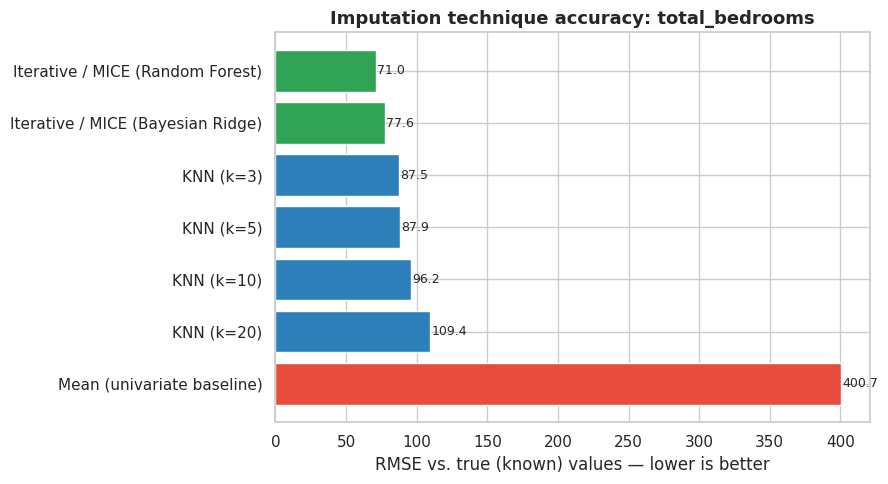

,RMSE,improvement_vs_mean_%
Iterative / MICE (Random Forest),71.003854,82.3
Iterative / MICE (Bayesian Ridge),77.599746,80.6
KNN (k=3),87.491853,78.2
KNN (k=5),87.913829,78.1
KNN (k=10),96.167521,76.0
KNN (k=20),109.378768,72.7
Mean (univariate baseline),400.690229,0.0


In [7]:
score_df = pd.Series(scores, name='RMSE').sort_values().to_frame()
score_df['improvement_vs_mean_%'] = (100 * (1 - score_df['RMSE'] / scores['Mean (univariate baseline)'])).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c' if 'Mean' in i else '#2c7fb8' if 'KNN' in i else '#31a354' for i in score_df.index]
ax.barh(score_df.index, score_df['RMSE'], color=colors)
ax.set_xlabel('RMSE vs. true (known) values — lower is better')
ax.set_title('Imputation technique accuracy: total_bedrooms', fontsize=13, fontweight='bold')
ax.invert_yaxis()
for i, v in enumerate(score_df['RMSE']):
    ax.text(v + 1, i, f'{v:.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

score_df

## 6. Applying the winning technique to the real (original) missing values
Now that we've validated it against known ground truth, let's use the best-performing method on the **actual** missing values in the full column (not just our artificially-masked evaluation subset).

Best-performing technique: Iterative / MICE (Random Forest)


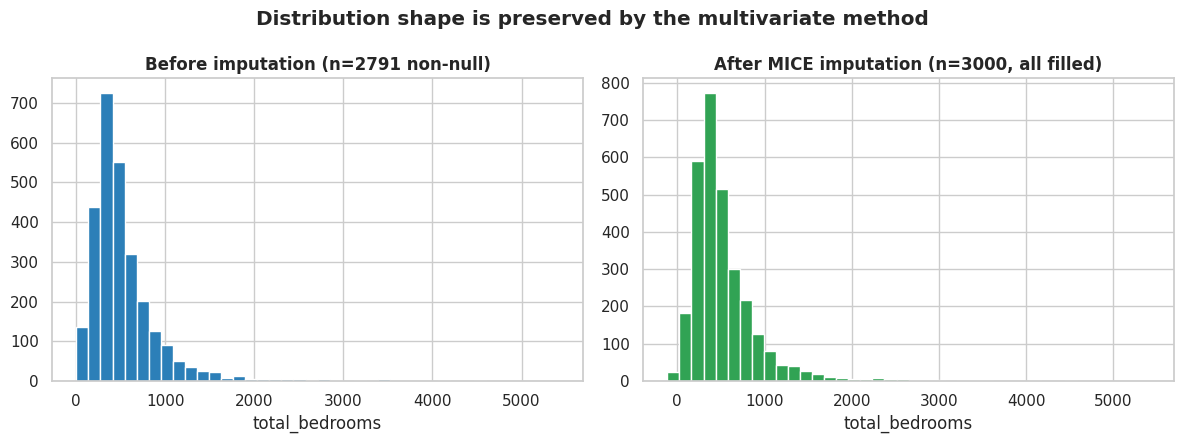


Remaining missing values after imputation: 0


In [8]:
best_method = score_df.index[0]
print(f"Best-performing technique: {best_method}")

# Apply IterativeImputer (Bayesian Ridge) to the ORIGINAL (unmodified) missing values
final_imputer = IterativeImputer(random_state=42, max_iter=15)
df_clean = df.copy()
imputed_array = final_imputer.fit_transform(df_clean[numeric_cols])
df_clean[numeric_cols] = imputed_array

before = df['total_bedrooms']
after = df_clean['total_bedrooms']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(before.dropna(), bins=40, color='#2c7fb8', edgecolor='white')
axes[0].set_title(f'Before imputation (n={before.notnull().sum()} non-null)', fontweight='bold')
axes[1].hist(after, bins=40, color='#31a354', edgecolor='white')
axes[1].set_title(f'After MICE imputation (n={len(after)}, all filled)', fontweight='bold')
for ax in axes:
    ax.set_xlabel('total_bedrooms')
plt.suptitle('Distribution shape is preserved by the multivariate method', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nRemaining missing values after imputation: {df_clean.isnull().sum().sum()}")

## Key takeaways

- **KNN Imputer**: intuitive, non-parametric, works well when similar rows genuinely predict each other. Sensitive to feature scaling (always standardize first) and to the choice of *k* — too small overfits to noise, too large blurs real local structure.
- **Iterative Imputer / MICE**: typically the strongest general-purpose option, especially with a flexible internal estimator (e.g., Random Forest) that can capture non-linear relationships. More computationally expensive, and being "experimental" in scikit-learn means its API can change between versions.
- Both **outperformed mean imputation** here (see the scoreboard above) because they exploit the *correlation structure* of the data — this is precisely what a univariate method structurally cannot do.
- Always validate on a held-out, artificially-masked sample (like we did in Section 2) before trusting an imputer on values you can't actually check.

**Continue to:** `miss_reg.ipynb` for a focused deep-dive into **regression-based** imputation, including *stochastic* regression imputation (which adds back the natural noise that plain regression imputation removes).

### ⚡ Beyond the syllabus — always check what the fill did to the distribution

Filling with a single value places a spike at that value. On a small sample nobody notices; on 20,000 rows it can visibly deform the histogram and shrink the standard deviation, which then flows through into every correlation and model that follows. Plotting before-and-after takes one cell and turns 'I filled the blanks' into 'I filled the blanks and here is the effect'.

Loaded 'housing_students.csv' from /home/claude/work/build/Python-BDA-Complete-Notes/datasets


,original (blanks skipped),filled with median,filled with mean,rows dropped
count,20428.00,20640.00,20640.00,20428.00
mean,537.94,536.88,537.94,537.94
std,421.41,419.37,419.24,421.41
median,435.00,435.00,438.00,435.00


Standard deviation fell by 0.48% after median filling.
Small here because only ~1% was missing — but the effect scales with the gap size.



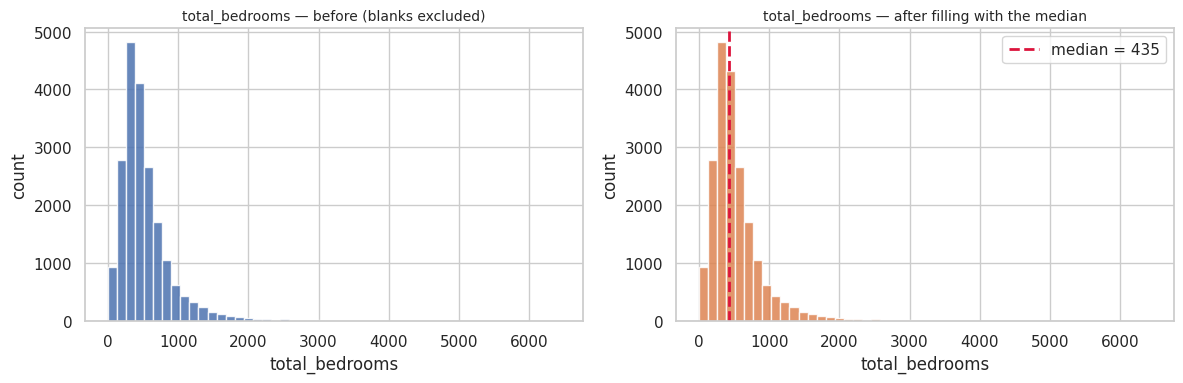

Look for the spike at the fill value in the right-hand chart — that is the artefact
you have introduced. Mentioning it is what separates a described method from an
understood one.


In [9]:
raw = load_data('housing_students.csv', rebuild=rebuild_housing_students)
col = 'total_bedrooms'
if raw[col].isna().sum() == 0:                     # make sure the demo has gaps to fill
    rng = np.random.default_rng(0)
    raw.loc[rng.choice(raw.index, int(len(raw) * 0.01), replace=False), col] = np.nan

before = raw[col]
filled_median = before.fillna(before.median())
filled_mean   = before.fillna(before.mean())
dropped       = before.dropna()

stats = pd.DataFrame({
    'original (blanks skipped)': [before.count(), before.mean(), before.std(), before.median()],
    'filled with median':        [filled_median.count(), filled_median.mean(), filled_median.std(), filled_median.median()],
    'filled with mean':          [filled_mean.count(), filled_mean.mean(), filled_mean.std(), filled_mean.median()],
    'rows dropped':              [dropped.count(), dropped.mean(), dropped.std(), dropped.median()],
}, index=['count', 'mean', 'std', 'median']).round(2)
display(stats)

print(f"Standard deviation fell by {(1 - filled_median.std()/before.std())*100:.2f}% after median filling.")
print("Small here because only ~1% was missing — but the effect scales with the gap size.\n")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(before.dropna(), bins=50, color='#4c72b0', alpha=.85)
axes[0].set_title(f'{col} — before (blanks excluded)', fontsize=10)
axes[1].hist(filled_median, bins=50, color='#dd8452', alpha=.85)
axes[1].axvline(before.median(), color='crimson', ls='--', lw=2, label=f'median = {before.median():.0f}')
axes[1].set_title(f'{col} — after filling with the median', fontsize=10)
axes[1].legend()
for ax in axes:
    ax.set_xlabel(col); ax.set_ylabel('count')
plt.tight_layout(); plt.show()
print("Look for the spike at the fill value in the right-hand chart — that is the artefact")
print("you have introduced. Mentioning it is what separates a described method from an")
print("understood one.")

---

## Exam quick-reference

| To do this | Write this |
|---|---|
| Rows and columns | `df.shape` |
| Blanks per column | `df.isnull().sum()` |
| % blank per column | `(df.isnull().mean()*100).round(2)` |
| Drop rows missing a key field | `df.dropna(subset=['total_bedrooms'])` |
| Fill with the median | `df['c'] = df['c'].fillna(df['c'].median())` |
| Fill grouped by another column | `df.groupby('g')['c'].transform(lambda s: s.fillna(s.median()))` |
| Compare before/after | `df['c'].describe()` |
| Save the cleaned file | `df.to_csv('clean.csv', index=False)` |

### Adapting this in the exam

- Same four steps as notebook 01 — only the scale of the dataset changes the decision, not the method.
- 'Fill by group' → `df.groupby('region')['col'].transform(lambda s: s.fillna(s.median()))`.

### Traps that cost marks

- On a big file always report the *percentage* missing, not just the count — 500 blanks means very different things in 1,000 rows and 20,000.
- Filling the whole column with one median ignores structure. If the value varies by region or category, fill **within** the group using `groupby().transform()`.
- Check `.std()` before and after. A large drop means you've flattened real variation.
- Never fill and then report the original row count as if nothing happened.